In [19]:
import pandas as pd

dataset = 'nhanes'

experiments_df = pd.read_csv(f'{dataset}_experiments.csv')

experiments_df.groupby(['loss']).agg({'ACC': ['mean', 'std'],
                                      '1OFF': ['mean', 'std'],
                                      'MAE': ['mean', 'std'],
                                      'MSE': ['mean', 'std'],
                                      'QWK': ['mean', 'std'],
                                      'AMAE': ['mean', 'std'],
                                      'MMAE': ['mean', 'std']
                                      })

ACC                1OFF                 MAE            \
                      mean       std      mean       std      mean       std   
loss                                                                           
COPOC             0.426469  0.009772  0.892287  0.005975  0.686086  0.012143   
CrossEntropyLoss  0.424325  0.009054  0.890794  0.005040  0.687196  0.010611   

                       MSE                 QWK                AMAE            \
                      mean       std      mean       std      mean       std   
loss                                                                           
COPOC             0.920880  0.022798  0.327320  0.018678  1.004631  0.019237   
CrossEntropyLoss  0.914871  0.018421  0.279539  0.016344  1.044267  0.016079   

                      MMAE            
                      mean       std  
loss                                  
COPOC             1.697436  0.061512  
CrossEntropyLoss  1.840513  0.053407

In [20]:
experiments_df.groupby(['loss']).agg({
    'RPS': ['mean', 'std'],
    'BS': ['mean', 'std'],
    'ECE': ['mean', 'std'],
    'CONF': ['mean', 'std'],
    'UMOD': ['mean', 'std'],
    'VAR': ['mean', 'std']
})

RPS                  BS                 ECE            \
                      mean       std      mean       std      mean       std   
loss                                                                           
COPOC             0.481628  0.005333  0.693902  0.004402  0.013697  0.002768   
CrossEntropyLoss  0.477545  0.004939  0.686181  0.003868  0.013754  0.003905   

                      CONF              UMOD                 VAR            
                      mean       std    mean       std      mean       std  
loss                                                                        
COPOC             0.452759  0.001910  1.0000  0.000000  0.856030  0.005072  
CrossEntropyLoss  0.443189  0.001704  0.9431  0.004983  0.825964  0.003920

In [21]:
experiments_cp_df = pd.read_csv(f'{dataset}_experiments_cp.csv')

# Define filters
experiments_cp_df['Method'] = ""
experiments_cp_df['Method'][(experiments_cp_df['loss'] == 'CrossEntropyLoss') & (experiments_cp_df['score'] == 'LAC')] = 'LAC'
experiments_cp_df['Method'][(experiments_cp_df['loss'] == 'CrossEntropyLoss') & (experiments_cp_df['score'] == 'APS')]= 'APS'
experiments_cp_df['Method'][(experiments_cp_df['loss'] == 'CrossEntropyLoss') & (experiments_cp_df['score'] == 'RPS')]= 'RPS'
experiments_cp_df['Method'][(experiments_cp_df['loss'] == 'CrossEntropyLoss') & (experiments_cp_df['score'] == 'min-CPS')]= 'min-CPS'
experiments_cp_df['Method'][(experiments_cp_df['loss'] == 'CrossEntropyLoss') & (experiments_cp_df['score'] == 'OCDF')]= 'OCDF'
experiments_cp_df['Method'][(experiments_cp_df['loss'] == 'COPOC') & (experiments_cp_df['score'] == 'LAC')] = 'COPOCL'
experiments_cp_df['Method'][(experiments_cp_df['loss'] == 'COPOC') & (experiments_cp_df['score'] == 'APS')] = 'COPOCA'

condition = (
        (experiments_cp_df['Method'] == "LAC")
        | (experiments_cp_df['Method'] == "APS")
        | (experiments_cp_df['Method'] == "RPS")
        | (experiments_cp_df['Method'] == "min-CPS")
        | (experiments_cp_df['Method'] == "COPOCL")
        | (experiments_cp_df['Method'] == "COPOCA")
        | (experiments_cp_df['Method'] == "OCDF")
)

# Apply filter
df_filt = experiments_cp_df[condition].copy()

df_filt

,iteration,loss,score,ALPHA,COV,PS,MW,MAMM,WAMM,AISL,MASE,CV%,Method
30,0,COPOC,APS,0.01,0.985646,4.430622,3.430622,1.066667,2.0,6.492823,0.015311,0.000000,COPOCA
31,0,COPOC,APS,0.02,0.975120,4.178947,3.178947,1.038462,2.0,5.762679,0.025837,0.000000,COPOCA
32,0,COPOC,APS,0.03,0.959809,3.876555,2.876555,1.047619,2.0,5.683573,0.042105,0.000000,COPOCA
33,0,COPOC,APS,0.05,0.937799,3.622967,2.622967,1.076923,2.0,5.302392,0.066986,0.000000,COPOCA
34,0,COPOC,APS,0.08,0.893780,3.206699,2.206699,1.072072,2.0,5.053589,0.113876,0.000000,COPOCA
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,49,CrossEntropyLoss,LAC,0.10,0.890909,2.911962,1.922488,1.078947,2.0,4.200000,0.117703,0.010526,LAC
4996,49,CrossEntropyLoss,LAC,0.13,0.873684,2.763636,1.768421,1.083333,2.0,3.844240,0.136842,0.004785,LAC
4997,49,CrossEntropyLoss,LAC,0.15,0.853589,2.606699,1.610526,1.071895,2.0,3.690271,0.156938,0.003828,LAC
4998,49,CrossEntropyLoss,LAC,0.18,0.815311,2.386603,1.390431,1.077720,2.0,3.591388,0.199043,0.003828,LAC


In [22]:
res_filt = df_filt.groupby(['ALPHA', 'Method']).agg({
    'COV': ['mean', 'std'],
    'PS': ['mean', 'std'],
    'MW': ['mean', 'std'],
    'CV%': ['mean', 'std'],
    'MAMM': ['mean', 'std'],
    'WAMM': ['mean', 'std'],
    'MASE': ['mean', 'std'],
    'AISL': ['mean', 'std'],
})
res_filt.index

MultiIndex([(              0.01,     'APS'),
            (              0.01,  'COPOCA'),
            (              0.01,  'COPOCL'),
            (              0.01,     'LAC'),
            (              0.01,    'OCDF'),
            (              0.01,     'RPS'),
            (              0.01, 'min-CPS'),
            (              0.02,     'APS'),
            (              0.02,  'COPOCA'),
            (              0.02,  'COPOCL'),
            (              0.02,     'LAC'),
            (              0.02,    'OCDF'),
            (              0.02,     'RPS'),
            (              0.02, 'min-CPS'),
            (              0.03,     'APS'),
            (              0.03,  'COPOCA'),
            (              0.03,  'COPOCL'),
            (              0.03,     'LAC'),
            (              0.03,    'OCDF'),
            (              0.03,     'RPS'),
            (              0.03, 'min-CPS'),
            (              0.05,     'APS'),
          

In [23]:
res = res_filt.loc[0.0999999999999999]
res_fmt = pd.DataFrame({})
res_fmt['COV'] = res[( 'COV', 'mean')].round(3).astype(str) + ' \\textpm ' + res[( 'COV',  'std')].round(3).astype(str)
res_fmt['PS'] = res[( 'PS', 'mean')].round(3).astype(str) + ' \\textpm ' + res[( 'PS',  'std')].round(3).astype(str)
res_fmt['CV'] = res[( 'CV%', 'mean')].round(3).astype(str) + ' \\textpm ' + res[( 'CV%',  'std')].round(3).astype(str)
res_fmt['MW'] = res[( 'MW', 'mean')].round(3).astype(str) + ' \\textpm ' + res[( 'MW',  'std')].round(3).astype(str)
res_fmt['MAMM'] = res[( 'MAMM', 'mean')].round(3).astype(str) + ' \\textpm ' + res[( 'MAMM',  'std')].round(3).astype(str)
res_fmt['WAMM'] = res[( 'WAMM', 'mean')].round(3).astype(str) + ' \\textpm ' + res[( 'WAMM',  'std')].round(3).astype(str)
res_fmt['MASE'] = res[( 'MASE', 'mean')].round(3).astype(str) + ' \\textpm ' + res[( 'MASE',  'std')].round(3).astype(str)
res_fmt['AISL'] = res[( 'AISL', 'mean')].round(3).astype(str) + ' \\textpm ' + res[( 'AISL',  'std')].round(3).astype(str)
res_fmt

,COV,PS,CV,MW,MAMM,WAMM,MASE,AISL
Method,,,,,,,,
APS,0.899 \textpm 0.012,3.101 \textpm 0.059,0.03 \textpm 0.005,2.131 \textpm 0.059,1.065 \textpm 0.02,2.12 \textpm 0.48,0.107 \textpm 0.013,4.197 \textpm 0.194
COPOCA,0.899 \textpm 0.011,3.126 \textpm 0.067,0.0 \textpm 0.0,2.126 \textpm 0.067,1.081 \textpm 0.021,2.2 \textpm 0.606,0.109 \textpm 0.012,4.3 \textpm 0.192
COPOCL,0.9 \textpm 0.012,3.061 \textpm 0.068,0.0 \textpm 0.0,2.061 \textpm 0.068,1.106 \textpm 0.021,2.0 \textpm 0.0,0.111 \textpm 0.013,4.284 \textpm 0.206
LAC,0.9 \textpm 0.013,2.967 \textpm 0.052,0.007 \textpm 0.002,1.974 \textpm 0.052,1.082 \textpm 0.019,2.0 \textpm 0.0,0.108 \textpm 0.014,4.109 \textpm 0.219
OCDF,0.902 \textpm 0.009,4.026 \textpm 0.03,0.0 \textpm 0.0,3.026 \textpm 0.03,1.101 \textpm 0.022,2.78 \textpm 0.418,0.108 \textpm 0.011,5.196 \textpm 0.188
RPS,0.9 \textpm 0.012,3.003 \textpm 0.049,0.0 \textpm 0.0,2.003 \textpm 0.049,1.048 \textpm 0.016,1.98 \textpm 0.141,0.105 \textpm 0.012,4.102 \textpm 0.197
min-CPS,0.9 \textpm 0.011,3.022 \textpm 0.062,0.0 \textpm 0.0,2.022 \textpm 0.062,1.065 \textpm 0.018,2.0 \textpm 0.0,0.106 \textpm 0.012,4.15 \textpm 0.188


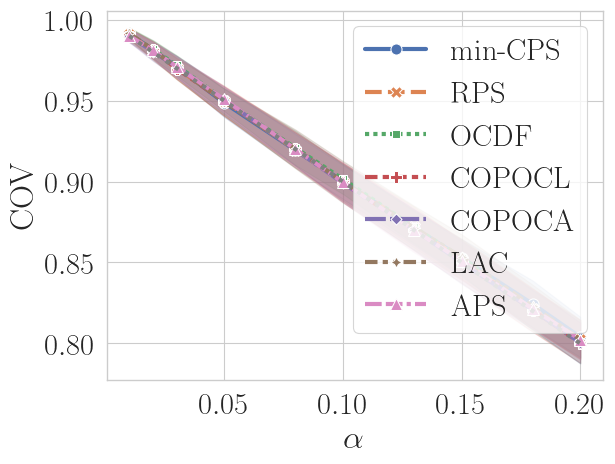

In [24]:
import seaborn as sns

sns.set_theme(context='paper', style='whitegrid', font_scale=2.5, font="serif", rc={
    "text.usetex": True,
    "lines.markersize": 8,
    "lines.linewidth": 3
})


methods = ['min-CPS', 'RPS', 'OCDF', 'COPOCL','COPOCA','LAC','APS']


g = sns.lineplot(data=df_filt, x="ALPHA", y="COV", hue="Method", style="Method", markers=True,
                 errorbar='sd', hue_order=
                 methods, style_order=
                 methods)

sns.lineplot(x=[0.2, 0.01], y=[0.8, 0.99], color='gray', linestyle=':')
g.set_xlabel('$\\alpha$')
g.set_ylabel('COV')

fig = g.get_figure()
fig.savefig(f'cov_{dataset}.pdf', bbox_inches='tight', dpi=300)

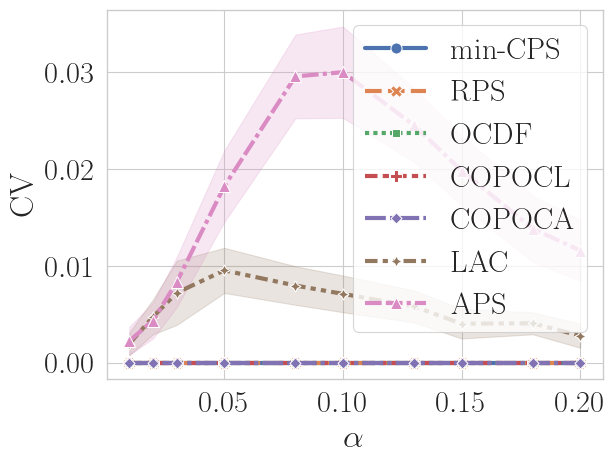

In [25]:
g = sns.lineplot(data=df_filt, x="ALPHA", y="CV%", hue="Method", style="Method", markers=True,
                 errorbar='sd', hue_order=
                 methods, style_order=
                 methods)
g.set_xlabel('$\\alpha$')
g.set_ylabel('CV')
g.get_legend().set_title('')
fig = g.get_figure()
fig.savefig(f'cv_{dataset}.pdf', bbox_inches='tight', dpi=300)

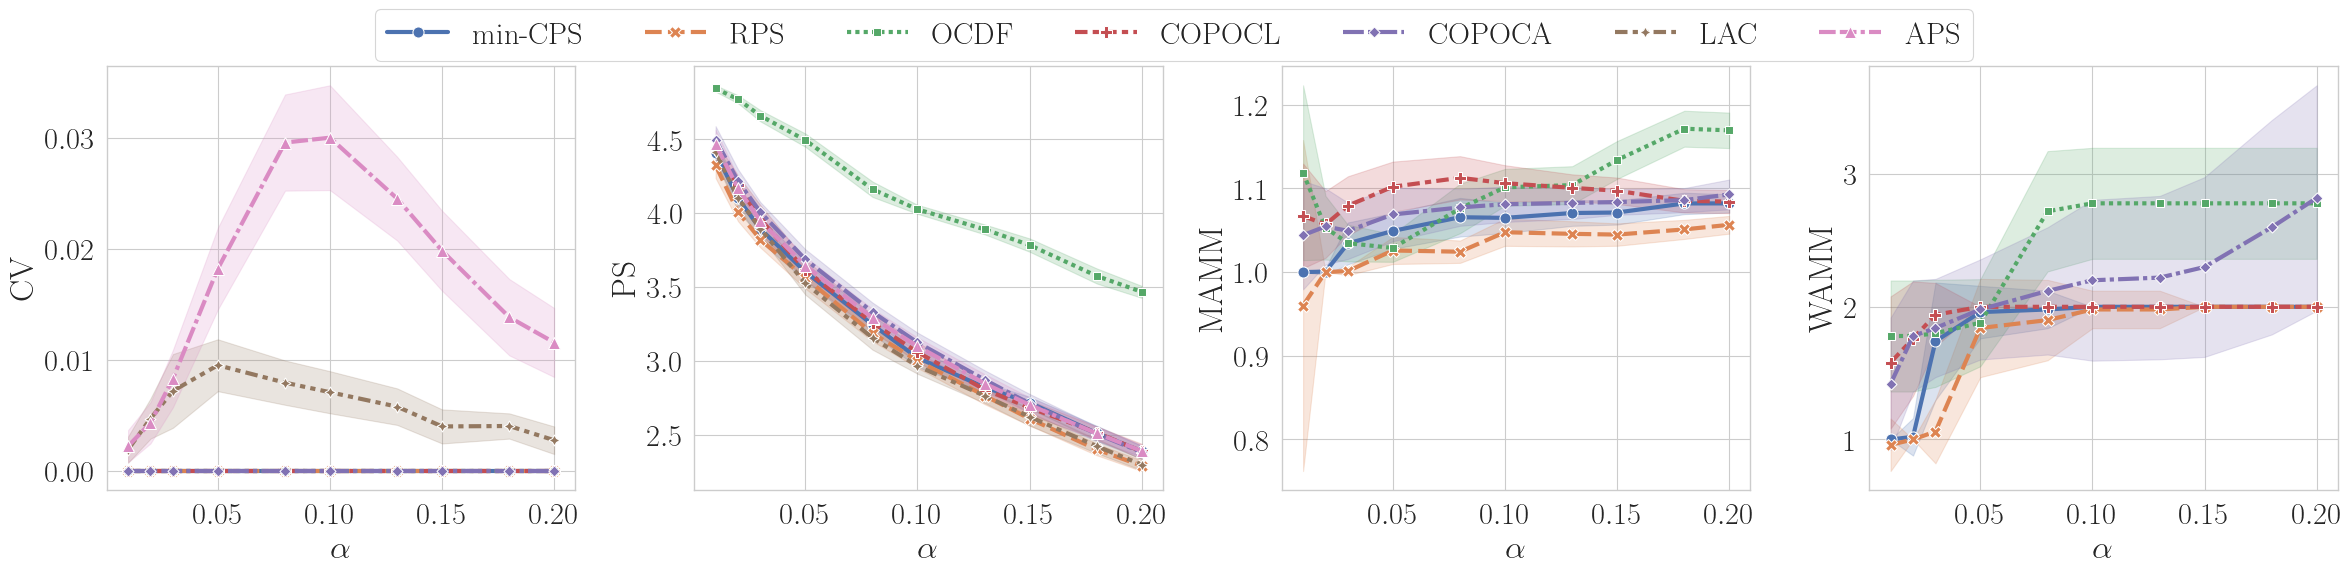

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 4, figsize=(24, 6), sharex=True)
metrics = [("CV%", "CV"), ("PS", "PS"), ("MAMM", "MAMM"), ("WAMM", "WAMM")]
hue_order = methods
style_order = methods

for i, (ax, (col, ylabel)) in enumerate(zip(axes, metrics)):

    if col == "MW" or col == "AISL" or  col == "MASE" or col == "MAMM" or col == "WAMM":
        if methods.count("LAC") == 1:
            methods.remove('LAC')
        if methods.count("APS") == 1:
            methods.remove('APS')
    elif col == "COV" or col== 'CV' or col=='PS':
          if methods.count("LAC") != 1:
            methods.append('LAC')
          if methods.count("APS") != 1:
            methods.append('APS')

    g = sns.lineplot(
        data=df_filt,
        x="ALPHA", y=col, hue="Method", style="Method",
        markers=True, errorbar='sd',
        hue_order=hue_order, style_order=style_order, ax=ax
    )
    ax.set_xlabel('$\\alpha$')
    ax.set_ylabel(ylabel)
    ax.get_legend().remove()

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=10, frameon=True,bbox_to_anchor=(0.5, 1.01))
plt.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig(f'ord_plots_{dataset}.pdf', bbox_inches='tight', dpi=300)
plt.show()

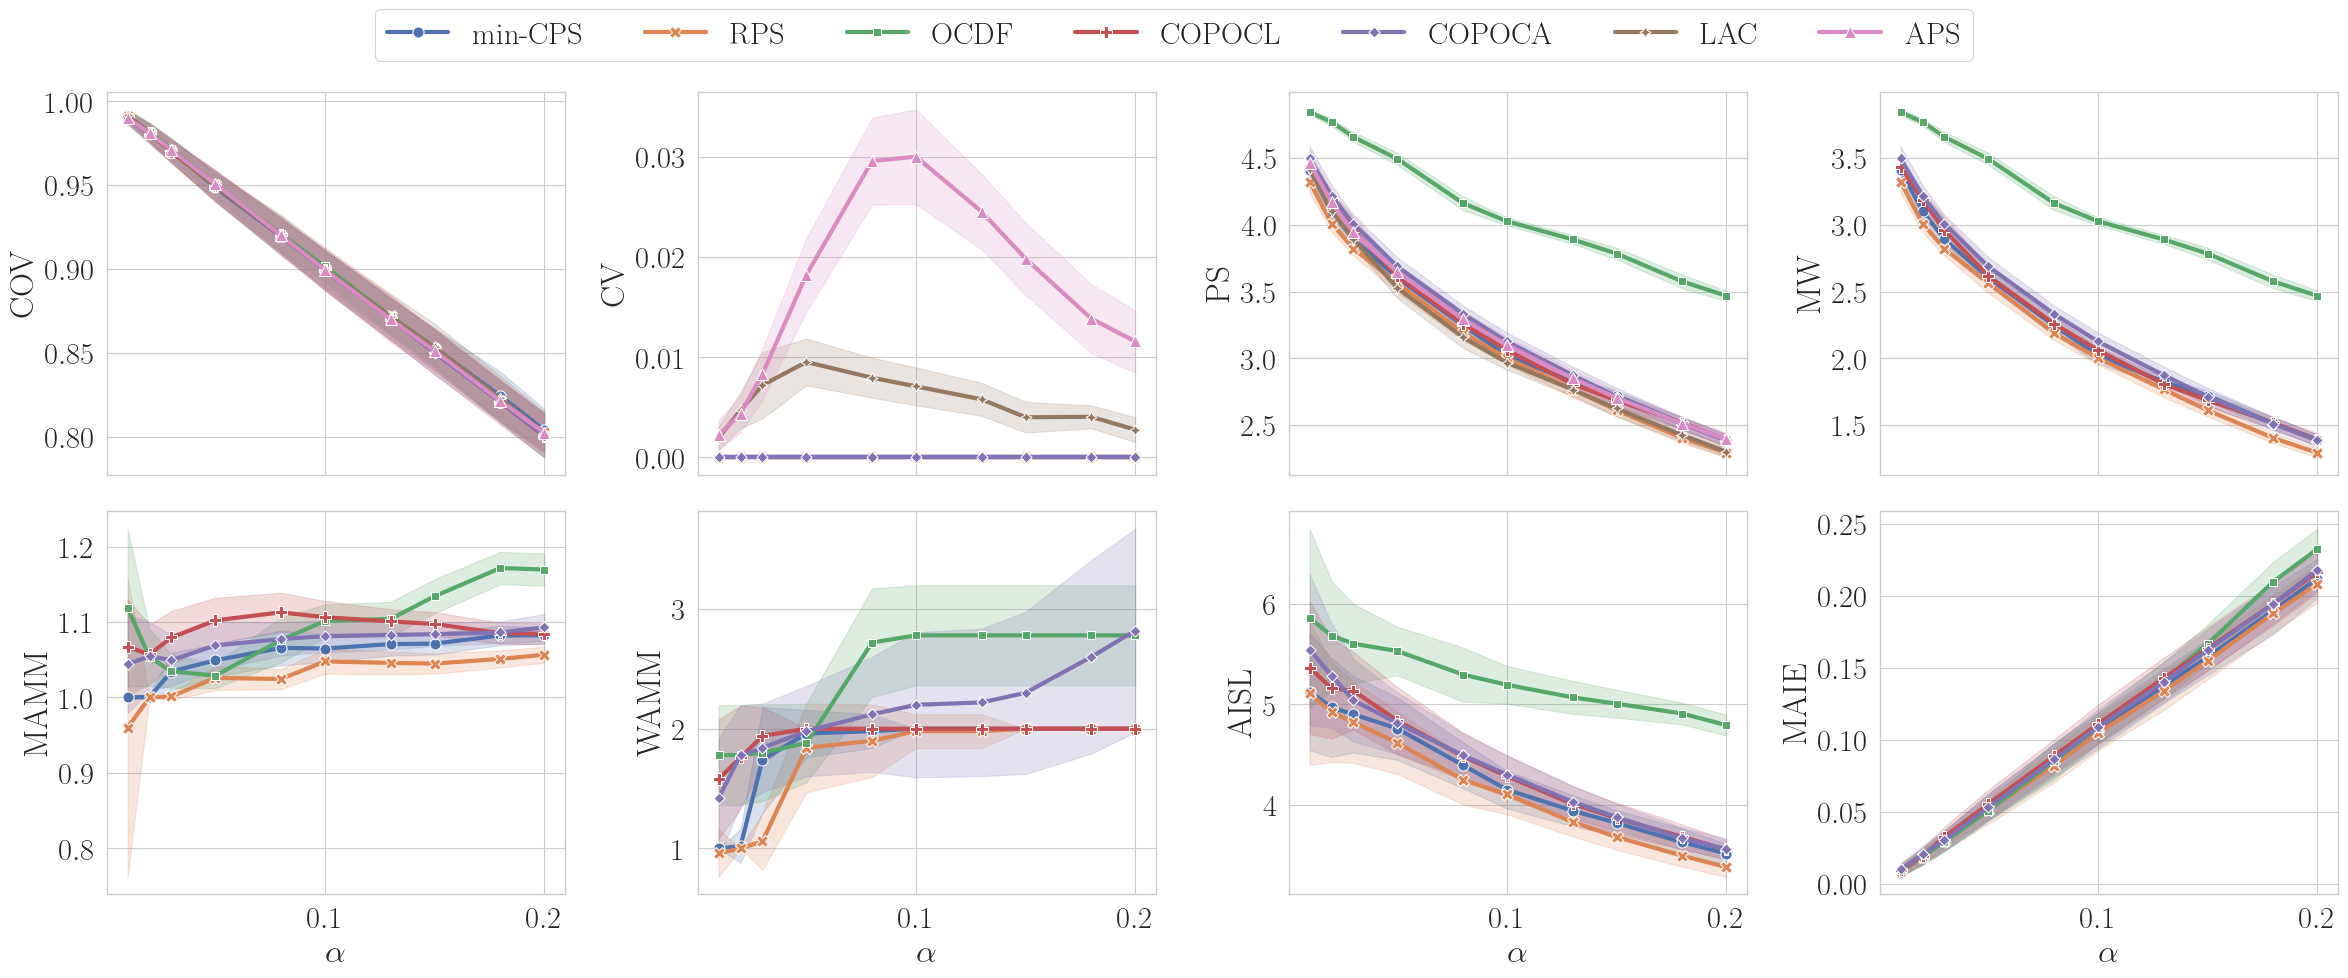

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

fig, axes = plt.subplots(2, 4, figsize=(24, 10), sharex=True)
axes = np.array(axes).ravel()
metrics = [("COV", "COV"), ("CV%", "CV"), ("PS", "PS"), ("MW","MW"), ("MAMM", "MAMM"), ("WAMM", "WAMM"), ("AISL", "AISL"), ("MASE", "MAIE")]


for i, (ax, (col, ylabel)) in enumerate(zip(axes, metrics)):

    if col == "MW" or col == "AISL" or  col == "MASE" or col == "MAMM" or col == "WAMM":
        if methods.count("LAC") == 1:
            methods.remove('LAC')
        if methods.count("APS") == 1:
            methods.remove('APS')
    elif col == "COV" or col== 'CV' or col=='PS':
          if methods.count("LAC") != 1:
            methods.append('LAC')
          if methods.count("APS") != 1:
            methods.append('APS')

    hue_order = methods
    style_order = methods

    g = sns.lineplot(
        data=df_filt,
        x="ALPHA", y=col, hue="Method", style="Method",
        markers=True, errorbar='sd',
        hue_order=hue_order, style_order=style_order, ax=ax, dashes=False
    )
    ax.set_xlabel('$\\alpha$')
    ax.set_ylabel(ylabel)
    ax.get_legend().remove()

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=10, frameon=True,bbox_to_anchor=(0.5, 1.01))
plt.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig(f'ord_plots_{dataset}_full.pdf', bbox_inches='tight', dpi=300)
plt.show()


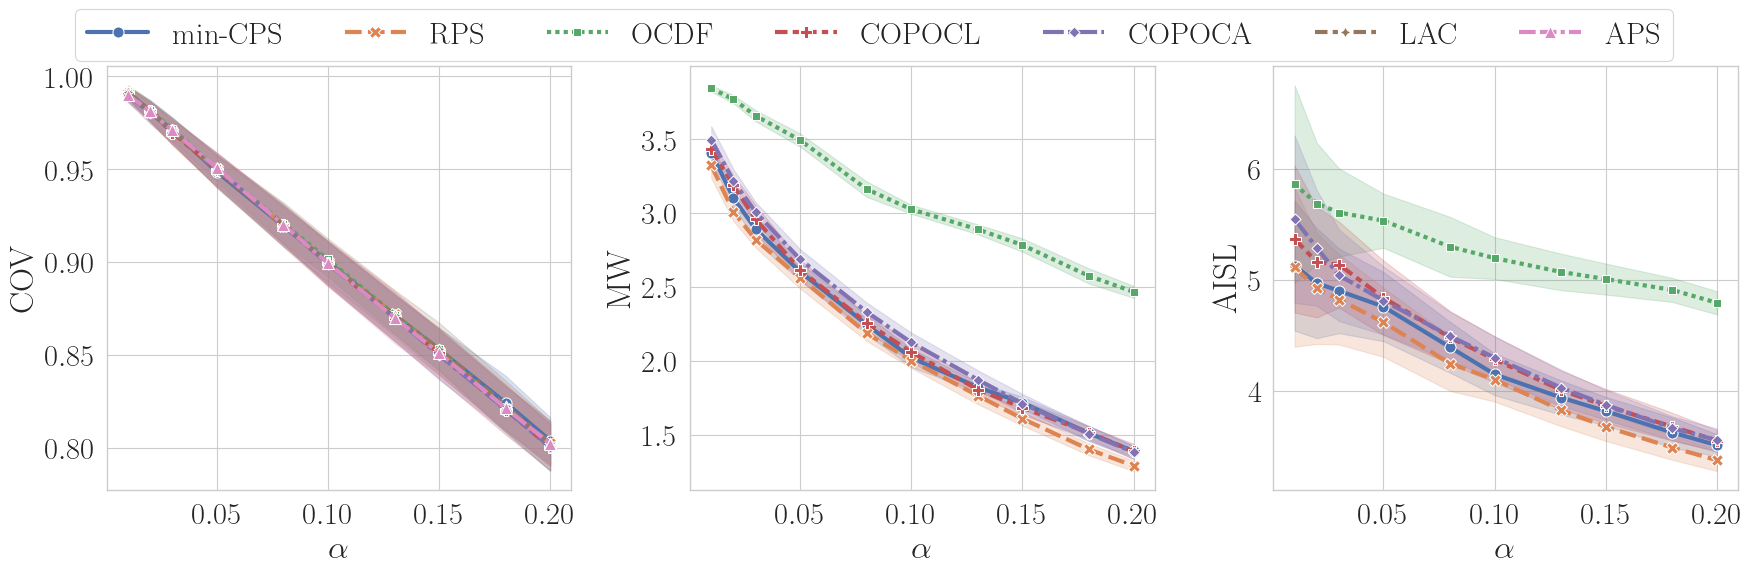

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharex=True)
metrics = [("COV", "COV"), ("MW", "MW"), ("AISL", "AISL")]

for i, (ax, (col, ylabel)) in enumerate(zip(axes, metrics)):

    if col == "MW" or col == "AISL" or  col == "MASE" or col == "MAMM" or col == "WAMM":
        if methods.count("LAC") == 1:
            methods.remove('LAC')
        if methods.count("APS") == 1:
            methods.remove('APS')
    elif col == "COV" or col== 'CV' or col=='PS':
          if methods.count("LAC") != 1:
            methods.append('LAC')
          if methods.count("APS") != 1:
            methods.append('APS')

    hue_order = methods
    style_order = methods

    g = sns.lineplot(
        data=df_filt,
        x="ALPHA", y=col, hue="Method", style="Method",
        markers=True, errorbar='sd',
        hue_order=hue_order, style_order=style_order, ax=ax
    )
    ax.set_xlabel('$\\alpha$')
    ax.set_ylabel(ylabel)
    ax.get_legend().remove()

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=10, frameon=True,bbox_to_anchor=(0.5, 1.01))
plt.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig(f'ord_plots_appendix_{dataset}.pdf', bbox_inches='tight', dpi=300)
plt.show()

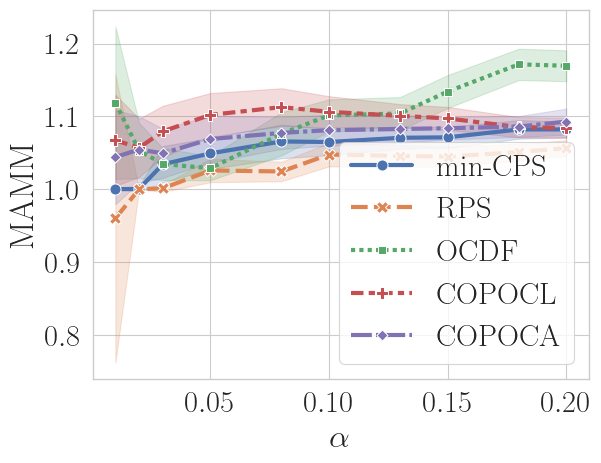

In [29]:
g = sns.lineplot(data=df_filt, x="ALPHA", y="MAMM", hue="Method", style="Method", markers=True,
                 errorbar='sd', hue_order=
                 methods, style_order=
                 methods)
g.set_xlabel('$\\alpha$')
g.set_ylabel('MAMM')
g.get_legend().set_title('')
fig = g.get_figure()
fig.savefig(f'mamm_{dataset}.pdf', bbox_inches='tight', dpi=300)

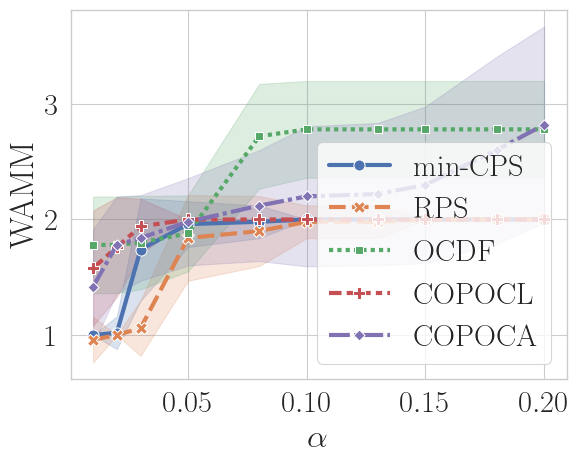

In [30]:
g = sns.lineplot(data=df_filt, x="ALPHA", y="WAMM", hue="Method", style="Method", markers=True,
                 errorbar='sd', hue_order=
                 methods, style_order=
                 methods)
g.set_xlabel('$\\alpha$')
g.set_ylabel('WAMM')
g.get_legend().set_title('')
fig = g.get_figure()
fig.savefig(f'wamm_{dataset}.pdf', bbox_inches='tight', dpi=300)

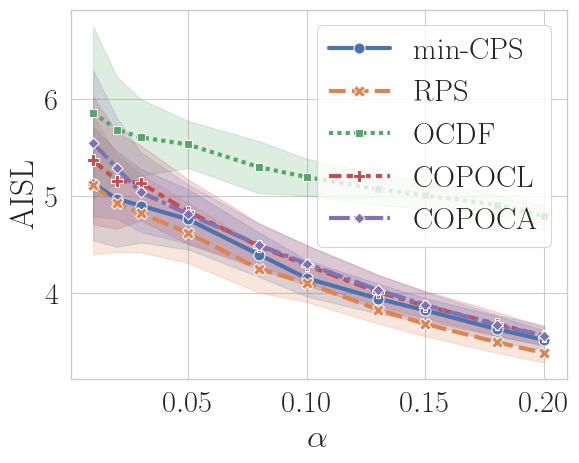

In [31]:
g = sns.lineplot(data=df_filt, x="ALPHA", y="AISL", hue="Method", style="Method", markers=True,
                 errorbar='sd', hue_order=
                 methods, style_order=
                 methods)
g.set_xlabel('$\\alpha$')
g.set_ylabel('AISL')
g.get_legend().set_title('')
fig = g.get_figure()
fig.savefig(f'aisl_{dataset}.pdf', bbox_inches='tight', dpi=300)

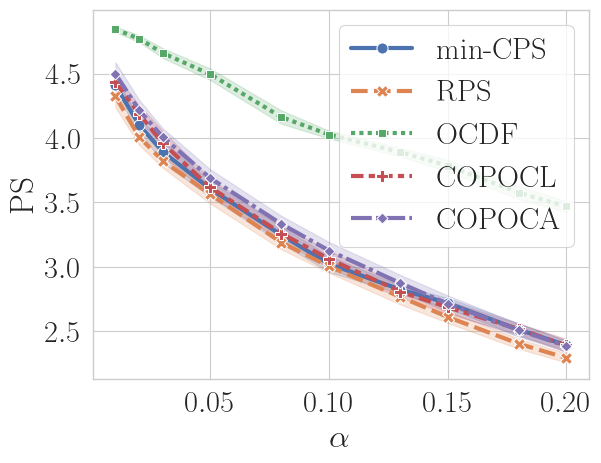

In [32]:
g = sns.lineplot(data=df_filt, x="ALPHA", y="PS", hue="Method", style="Method", markers=True,
                 errorbar='sd', hue_order=
                 methods, style_order=
                 methods)
g.get_legend().set_title('')
g.set_xlabel('$\\alpha$')
g.set_ylabel('PS')
g.get_legend().set_title('')
fig = g.get_figure()
fig.savefig(f'ps_{dataset}.pdf', bbox_inches='tight', dpi=300)

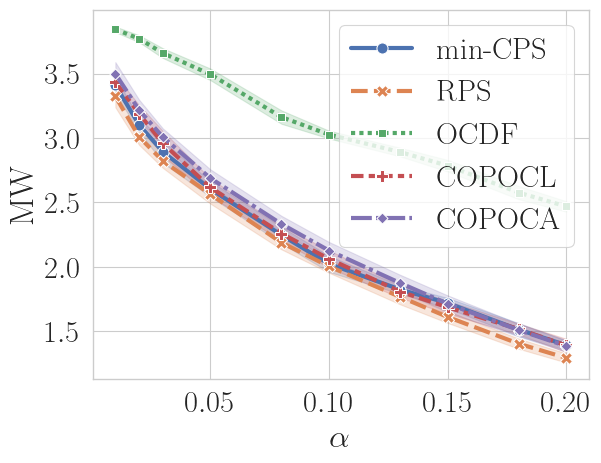

In [33]:
g = sns.lineplot(data=df_filt, x="ALPHA", y="MW", hue="Method", style="Method", markers=True,
                 errorbar='sd', hue_order=
                 methods, style_order=
                 methods)
g.get_legend().set_title('')
g.set_xlabel('$\\alpha$')
g.set_ylabel('MW')
fig = g.get_figure()
fig.savefig(f'mw_{dataset}.pdf', bbox_inches='tight', dpi=300)

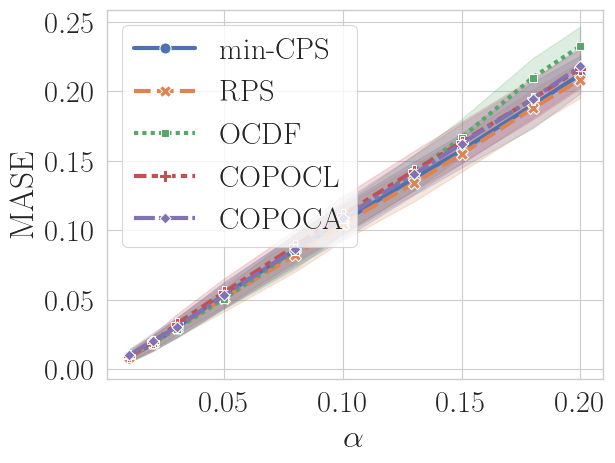

In [34]:
g = sns.lineplot(data=df_filt, x="ALPHA", y="MASE", hue="Method", style="Method", markers=True,
                 errorbar='sd', hue_order=
                 methods, style_order=
                 methods)
g.get_legend().set_title('')
g.set_xlabel('$\\alpha$')
g.set_ylabel('MASE')
fig = g.get_figure()
fig.savefig(f'mase_{dataset}.pdf', bbox_inches='tight', dpi=300)

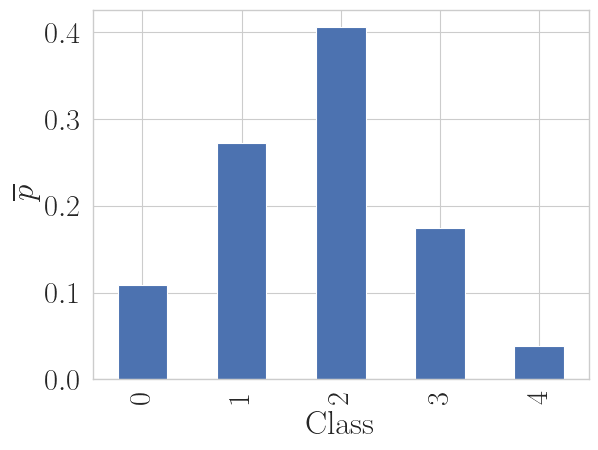

In [35]:
df_probas = pd.read_csv(f'probas_{dataset}_CrossEntropyLoss.csv', header=0, index_col=0)
g = df_probas.mean().plot(kind='bar')
g.set_xlabel('Class')
g.set_ylabel('$\\overline{p}$')
fig = g.get_figure()
fig.savefig(f'probas_{dataset}_CE.pdf', bbox_inches='tight', dpi=300)